In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/dhruvkp07/funnel-analysis-dataset/Funnel_Analysis_Data.csv


# E-Commerce Funnel & Conversion Analytics


# 1. Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Loading the dataset and viewing it

df = pd.read_csv("/kaggle/input/datasets/dhruvkp07/funnel-analysis-dataset/Funnel_Analysis_Data.csv")
df.head(5)

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes


In [4]:
# Getting the number of rows and columns and info about each column in data
print("Shape of dataset",df.shape)
print("\n")
df.info()


Shape of dataset (21409, 10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21409 entries, 0 to 21408
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User ID           21409 non-null  object 
 1   Session ID        21409 non-null  object 
 2   Event Time        21409 non-null  object 
 3   Event             21409 non-null  object 
 4   Device            21409 non-null  object 
 5   Region            21409 non-null  object 
 6   Channel           21409 non-null  object 
 7   Product Category  21409 non-null  object 
 8   Revenue           21409 non-null  float64
 9   Bonus Flag        21409 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.6+ MB


In [5]:
# Printing Cloumns and Unique values in each column

column = df.columns
for col in column:
    print(f"\n{col}:")
    print(df[col].unique())

# Printing the number of unique values in each column
print("\n -------The number of unique values in each column--------")
for col in column:   
    print(col,":", df[col].nunique())



User ID:
['USR-00001' 'USR-00002' 'USR-00003' ... 'USR-09998' 'USR-09999'
 'USR-10000']

Session ID:
['SES-00001' 'SES-00002' 'SES-00003' ... 'SES-09998' 'SES-09999'
 'SES-10000']

Event Time:
['2026-01-07 23:46:20.358501' '2026-01-07 23:49:20.358501'
 '2026-01-07 23:51:20.358501' ... '2025-12-17 06:22:57.577958'
 '2025-12-30 15:47:23.983289' '2025-12-19 18:57:10.591617']

Event:
['Browse' 'Add to Cart' 'Checkout' 'Purchase']

Device:
['Tablet' 'Desktop' 'Mobile']

Region:
['South' 'East' 'West' 'North']

Channel:
['Organic' 'Email' 'Google Ads' 'Social Media']

Product Category:
['Electronics' 'Sports' 'Fashion' 'Beauty' 'Home']

Revenue:
[  0.   427.16 201.08 141.85 492.44  76.57  82.88 107.64 294.7  489.91
 188.72 182.3  143.79 326.92 312.52 471.05 288.49 395.99 201.83 193.58
 302.26  87.97 486.58 301.84 176.68 113.5  265.33  80.46 479.37  84.91
 429.11 402.18 131.31 246.99 464.79  89.    54.28 247.91 396.89 176.43
 300.   260.4  107.15 354.49 406.52  60.36 470.67 210.   348.02 388

In [6]:
#The number of categories in each Categorical column
print("------The number of categories in each Categorical column-------")
categorical_cols = ["Event","Device","Region","Channel","Product Category","Bonus Flag"]
for categories in categorical_cols:
    print("\n",df[categories].value_counts())

------The number of categories in each Categorical column-------

 Event
Browse         10000
Add to Cart     6949
Checkout        3456
Purchase        1004
Name: count, dtype: int64

 Device
Desktop    7271
Tablet     7190
Mobile     6948
Name: count, dtype: int64

 Region
South    5466
East     5397
West     5278
North    5268
Name: count, dtype: int64

 Channel
Google Ads      5427
Email           5404
Organic         5378
Social Media    5200
Name: count, dtype: int64

 Product Category
Electronics    4435
Beauty         4353
Fashion        4289
Home           4185
Sports         4147
Name: count, dtype: int64

 Bonus Flag
Yes    20405
No      1004
Name: count, dtype: int64


# 2. Data Quality and Cleaning

In [7]:

print("----Null values in each column-----")
null_value_counts = df.isnull().sum()
print(null_value_counts)


print("\n ------The number of duplicate rows------")
dup_rows = df.duplicated().sum()
print("duplicate rows:",dup_rows)
print("\n")
print("----Data Type of each column----")
df.dtypes



----Null values in each column-----
User ID             0
Session ID          0
Event Time          0
Event               0
Device              0
Region              0
Channel             0
Product Category    0
Revenue             0
Bonus Flag          0
dtype: int64

 ------The number of duplicate rows------
duplicate rows: 0


----Data Type of each column----


User ID              object
Session ID           object
Event Time           object
Event                object
Device               object
Region               object
Channel              object
Product Category     object
Revenue             float64
Bonus Flag           object
dtype: object

In [8]:
# Fixing the datatype of Event time to datetime

df["Event Time"] = pd.to_datetime(df["Event Time"])
print(df["Event Time"].dtype)

# Deriving multiple columns from Event Time
df["Date"] = df["Event Time"].dt.date
df["DayOfWeek"] = df["Event Time"].dt.day_name()
df["Hour"] = df["Event Time"].dt.hour
df["WeekNumber"] = df["Event Time"].dt.isocalendar().week
df.head()

datetime64[ns]


,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag,Date,DayOfWeek,Hour,WeekNumber
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,Sunday,21,1
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,Sunday,21,1


In [9]:
# Feature Engineering Event Sequence with respect to Session ID which gives how many times a person visited or performed an Event

df["Event_Sequence"] = df.groupby("Session ID").cumcount()+1
df.head()

,User ID,Session ID,Event Time,Event,Device,Region,Channel,Product Category,Revenue,Bonus Flag,Date,DayOfWeek,Hour,WeekNumber,Event_Sequence
0,USR-00001,SES-00001,2026-01-07 23:46:20.358501,Browse,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2,1
1,USR-00001,SES-00001,2026-01-07 23:49:20.358501,Add to Cart,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2,2
2,USR-00001,SES-00001,2026-01-07 23:51:20.358501,Checkout,Tablet,South,Organic,Electronics,0.0,Yes,2026-01-07,Wednesday,23,2,3
3,USR-00002,SES-00002,2026-01-04 21:06:42.296010,Browse,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,Sunday,21,1,1
4,USR-00002,SES-00002,2026-01-04 21:10:42.296010,Add to Cart,Desktop,East,Email,Sports,0.0,Yes,2026-01-04,Sunday,21,1,2


In [10]:
print(f"Date range {df["Date"].min()} to {df["Date"].max()}")

Date range 2025-12-09 to 2026-01-08


In [11]:
df["Revenue"].describe()

count    21409.000000
mean        12.953574
std         65.005620
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        499.990000
Name: Revenue, dtype: float64

# Funnel Stage Definition and Session-Level Aggregation

In [12]:
# Define funnel stages in order
funnel_stages = ['Browse', 'Add to Cart', 'Checkout', 'Purchase']

# Create Session-level summary
session_summary = df.groupby("Session ID").agg({
    'User ID' : 'first' ,                  
    'Event Time'  : ["min","max"],       
    'Event'  : lambda x: list(x),          
    'Device'  :  'first',          
    'Region'  :  'first',           
    'Channel' :  'first',           
    'Product Category' : 'first',    
    'Revenue' :   'max' ,        
    'Bonus Flag' : 'first'          
}).reset_index()

# Flatten column names
session_summary.columns = ['Session ID','User ID', 'Session_Start','Session_End',
                          'Event_Sequence','Device','Region','Channel','Product Category',
                           'Revenue','Bonus Flag']

# Calculate session duration in minutes
session_summary['Session_Duration_Min'] = (session_summary['Session_End'] - session_summary['Session_Start']).dt.total_seconds() /60

# Identify maximum funnel stage reached for each session
def get_max_funnel_stage(events):
    stage_values = {stage:i for i,stage in enumerate(funnel_stages)}
    max_stage_index = -1
    for event in events:
        if event in stage_values and stage_values[event] > max_stage_index:
            max_stage_index = stage_values[event]
    return funnel_stages[max_stage_index] if max_stage_index != -1 else 'Browse'

session_summary["Max_Funnel_Stage"] = session_summary["Event_Sequence"].apply(get_max_funnel_stage)
print("Session Summary Created:")
display(session_summary.head())

Session Summary Created:


,Session ID,User ID,Session_Start,Session_End,Event_Sequence,Device,Region,Channel,Product Category,Revenue,Bonus Flag,Session_Duration_Min,Max_Funnel_Stage
0,SES-00001,USR-00001,2026-01-07 23:46:20.358501,2026-01-07 23:51:20.358501,"[Browse, Add to Cart, Checkout]",Tablet,South,Organic,Electronics,0.00,Yes,5.0,Checkout
1,SES-00002,USR-00002,2026-01-04 21:06:42.296010,2026-01-04 21:10:42.296010,"[Browse, Add to Cart]",Desktop,East,Email,Sports,0.00,Yes,4.0,Add to Cart
2,SES-00003,USR-00003,2025-12-19 20:49:00.895328,2025-12-19 20:49:00.895328,[Browse],Tablet,South,Email,Fashion,0.00,Yes,0.0,Browse
3,SES-00004,USR-00004,2026-01-08 07:58:00.840696,2026-01-08 08:02:00.840696,"[Browse, Add to Cart, Checkout]",Tablet,East,Organic,Sports,0.00,Yes,4.0,Checkout
4,SES-00005,USR-00005,2025-12-21 20:56:31.701462,2025-12-21 21:04:31.701462,"[Browse, Add to Cart, Checkout, Purchase]",Desktop,South,Google Ads,Beauty,427.16,Yes,8.0,Purchase


# Overall Funnel Analysis

In [13]:
# Calculate overall funnel metrics
funnel_metrics = []
for i,stage in enumerate(funnel_stages):
    if i==0:
        # For Browse stage, count all sessions
        count = len(session_summary)
    else:
        # For other stages, count sessions that reached at least this stage
        count = len(session_summary[session_summary["Max_Funnel_Stage"].isin(funnel_stages[i:])])

    funnel_metrics.append({
        "Stage" : stage,
        "Sessions" : count,
        "Stage_Order" : i
    })

funnel_df = pd.DataFrame(funnel_metrics)

# Calculate conversion rates 
funnel_df["Conversion_Rate"] = (funnel_df["Sessions"] / funnel_df["Sessions"].iloc[0] * 100).round(2)
funnel_df["Drop_off_rate"] = (1- funnel_df["Sessions"]/ funnel_df["Sessions"].shift(1)) * 100
funnel_df["Drop_off_rate"].iloc[0] = 0
funnel_df["Drop_off_rate"] = funnel_df["Drop_off_rate"].round(2)

print("Overall Funnel Analysis")
display(funnel_df)

# Revenue Analysis
revenue_stats = session_summary[session_summary["Max_Funnel_Stage"] == 'Purchase'].agg({
    "Revenue" : ["sum", "mean", "count"]
}).round(2)

print("\n Revenue Analysis")
print(f"Total Revenue: ${revenue_stats.iloc[0,0]:2f}")
print(f"Average Order Value: ${revenue_stats.iloc[1,0]:2f}")
print(f"Total Orders: {revenue_stats.iloc[2,0]:2f}")

Overall Funnel Analysis


/tmp/ipykernel_58/1114238577.py:22: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  funnel_df["Drop_off_rate"].iloc[0] = 0
/tmp/ipykernel_58/1114238577.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Dat

,Stage,Sessions,Stage_Order,Conversion_Rate,Drop_off_rate
0,Browse,10000,0,100.00,0.00
1,Add to Cart,6949,1,69.49,30.51
2,Checkout,3456,2,34.56,50.27
3,Purchase,1004,3,10.04,70.95



 Revenue Analysis
Total Revenue: $277323.060000
Average Order Value: $276.220000
Total Orders: 1004.000000


# Visualization - Overall Funnel

In [14]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create comprehensive funnel visualization
fig = make_subplots(
    rows = 2, cols = 2,
    subplot_titles = ('Funnel Conversion Rates','Stage to Stage Drop-off',
                      'Revenue by Funnel Stage','Session Duration by Stage'),
    specs = [[{"secondary_y":False},{"secondary_y":False}],
            [{"secondary_y":False},{"secondary_y":False}]]
)

#Funnel Conversion rates
fig.add_trace(
    go.Bar(x = funnel_df['Stage'] , y = funnel_df["Sessions"],
           text = funnel_df["Sessions"] , textposition = 'auto',
           name = 'Sessions', marker_color = 'lightblue'),
    row = 1 ,col = 1
)


# Drop-off rates
fig.add_trace(
    go.Scatter(x = funnel_df['Stage'] , y = funnel_df["Drop_off_rate"],
               mode = 'lines+markers+text',text = funnel_df["Drop_off_rate"],
               textposition = "top center",name = "Drop-off Rate(%)",
               line = dict(color = 'red',width = 3)),
    row = 1, col = 2 ,secondary_y = False
)

# Revenue by Stage
revenue_by_stage = session_summary.groupby("Max_Funnel_Stage")['Revenue'].mean().reset_index()
fig.add_trace(
    go.Bar(x = revenue_by_stage['Max_Funnel_Stage'] , y = revenue_by_stage["Revenue"],
           text = [f'$ {x:,.0f}' for x in revenue_by_stage["Revenue"]] ,
           textposition = 'auto', name = 'Revenue', marker_color = 'green'),
    row = 2 ,col = 1
)

# Session duration by stage
duration_by_stage = session_summary.groupby("Max_Funnel_Stage")['Session_Duration_Min'].mean().reset_index()
fig.add_trace(
    go.Bar(x = duration_by_stage['Max_Funnel_Stage'] , y = duration_by_stage["Session_Duration_Min"],
           text = duration_by_stage["Session_Duration_Min"].round(2) ,
           textposition = 'auto', name = 'Avg Session Duration(min)', marker_color = 'orange'),
    row = 2 ,col = 2
)

fig.update_layout(height = 880, title_text = "Comprehensive Funnel Analysis Dashboard", showlegend = False)
fig.show()

# Channel Performance Analysis

Channel Performance Analysis:


,Channel,Total_Sessions,Browse_Sessions,Browse_Rate,Add to Cart_Sessions,Add to Cart_Rate,Checkout_Sessions,Checkout_Rate,Purchase_Sessions,Purchase_Rate,Total_Revenue,AOV,Conversion_Rate
0,Organic,2528,2528,100.0,1745,69.03,866,34.26,239,9.45,65973.04,276.04,9.45
1,Email,2515,2515,100.0,1762,70.06,879,34.95,248,9.86,69126.46,278.74,9.86
2,Google Ads,2520,2520,100.0,1746,69.29,893,35.44,268,10.63,73862.32,275.61,10.63
3,Social Media,2437,2437,100.0,1696,69.59,818,33.57,249,10.22,68361.24,274.54,10.22


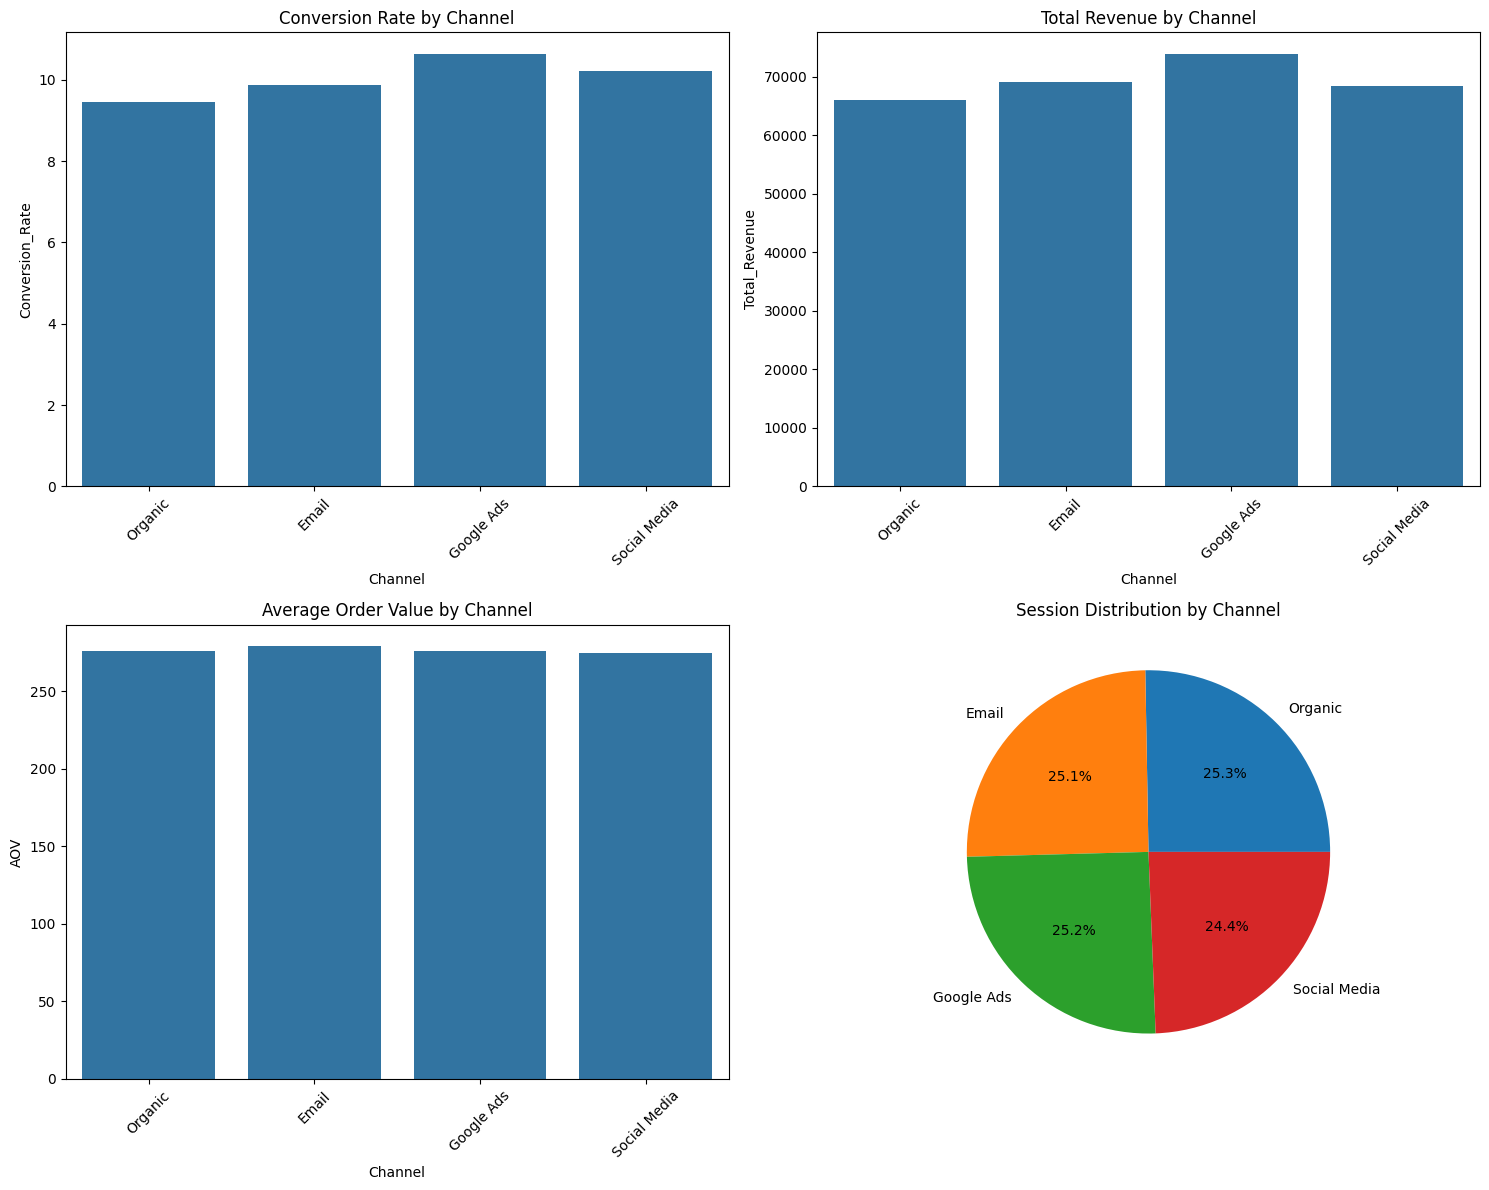

In [15]:
# Funnel analysis by channel
channel_funnel = []

for channel in df['Channel'].unique():
    channel_sessions = session_summary[session_summary['Channel'] == channel]
    total_sessions = len(channel_sessions)

    if total_sessions > 0:
        channel_metrics = {"Channel": channel,"Total_Sessions": total_sessions}

        for i, stage in enumerate(funnel_stages):
            if i == 0:
                count = total_sessions
            else:
                count = len(channel_sessions[channel_sessions["Max_Funnel_Stage"].isin(funnel_stages[i:])])

            channel_metrics[f"{stage}_Sessions"] = count
            channel_metrics[f"{stage}_Rate"] = (count / total_sessions * 100)

    # Revenue metrics
    purchase_sessions = channel_sessions[channel_sessions['Max_Funnel_Stage'] == 'Purchase']
    channel_metrics["Total_Revenue"] = purchase_sessions["Revenue"].sum()
    channel_metrics['AOV'] = purchase_sessions["Revenue"].mean() if len(purchase_sessions) > 0 else 0
    channel_metrics["Conversion_Rate"] = (len(purchase_sessions)/ total_sessions * 100)

    channel_funnel.append(channel_metrics)


channel_df = pd.DataFrame(channel_funnel)

print("Channel Performance Analysis:")
display(channel_df.round(2))

# Visualize channel performance
fig,((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2,figsize=(15,12))

# Conversion rates by channel
sns.barplot(data=channel_df, x= "Channel", y = "Conversion_Rate", ax = ax1)
ax1.set_title("Conversion Rate by Channel")
ax1.tick_params(axis = 'x', rotation = 45)

# Total revenue by channel
sns.barplot(data = channel_df, x= "Channel", y = "Total_Revenue", ax = ax2)
ax2.set_title("Total Revenue by Channel")
ax2.tick_params(axis = "x", rotation = 45)

# AOV by channel
sns.barplot(data = channel_df, x= "Channel", y = "AOV", ax = ax3)
ax3.set_title("Average Order Value by Channel")
ax3.tick_params(axis = "x", rotation = 45)

# Session distribution by channel
channel_df["Session_Percentage"] = (channel_df["Total_Sessions"]/ channel_df["Total_Sessions"].sum() * 100)
ax4.pie(channel_df["Session_Percentage"], labels = channel_df["Channel"], autopct = '%1.1f%%')
ax4.set_title("Session Distribution by Channel")

plt.tight_layout()
plt.show()


# Regional Analysis

Regional Performance


,Total_Sessions,Total_Revenue,Session_Duration_Min,Converted_Sessions,Conversion_Rate,AOV
Region,,,,,,
East,2548,66116.01,3.881083,245,9.62,269.86
North,2463,68645.13,3.988632,253,10.27,271.32
South,2543,77421.45,3.992922,268,10.54,288.89
West,2446,65140.47,4.087490,238,9.73,273.70


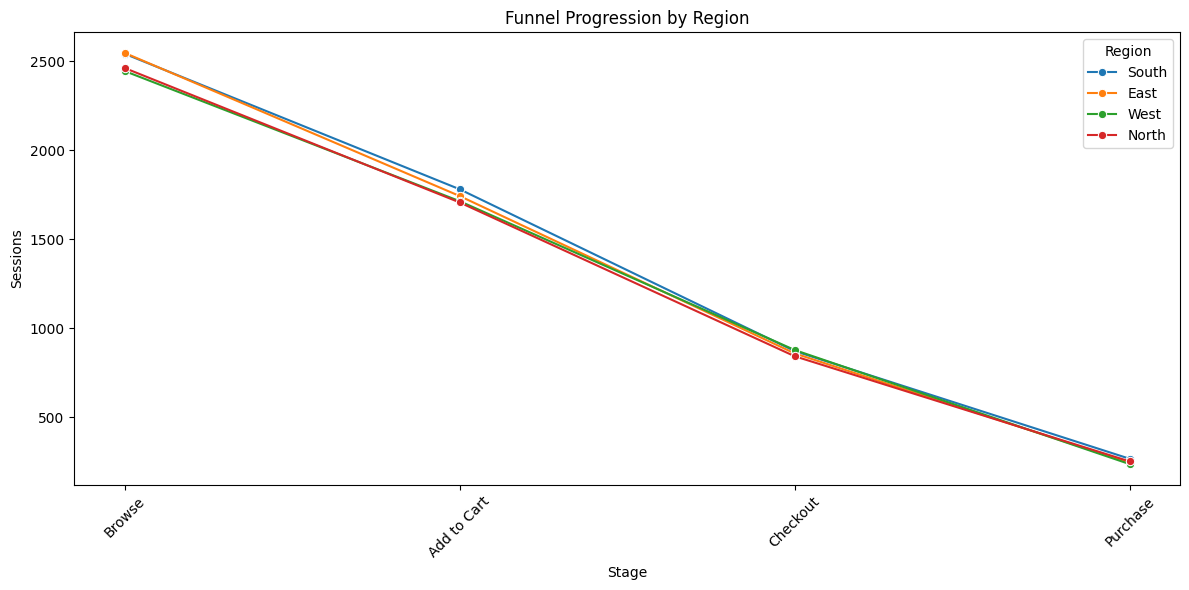

In [16]:
# Regional performance analysis
regional_analysis = session_summary.groupby("Region").agg({
    "Session ID": "count",
    "Revenue" : "sum",
    "Session_Duration_Min": "mean"
}).rename(columns = {"Session ID":"Total_Sessions","Revenue":"Total_Revenue"})

# Add conversion rates by region
regional_conversion = session_summary[session_summary["Max_Funnel_Stage"] == 'Purchase'].groupby("Region").size()
regional_analysis["Converted_Sessions"] = regional_conversion
regional_analysis["Conversion_Rate"] = (regional_analysis["Converted_Sessions"] / regional_analysis["Total_Sessions"] * 100).round(2)
regional_analysis["AOV"] = (regional_analysis["Total_Revenue"] / regional_analysis["Converted_Sessions"]).round(2)

print("Regional Performance")
display(regional_analysis)

# Regional funnel distribution
regional_funnel_data = []
for region in df['Region'].unique():
    region_sessions = session_summary[session_summary["Region"] == region]
    for stage in funnel_stages:
        if stage == "Browse":
            count = len(region_sessions)
        else:
            count = len(region_sessions[region_sessions["Max_Funnel_Stage"].isin(funnel_stages[funnel_stages.index(stage):])])
        regional_funnel_data.append({'Region': region, 'Stage': stage, 'Sessions':count})

regional_funnel_df = pd.DataFrame(regional_funnel_data)

plt.figure(figsize = (12,6))
sns.lineplot(data = regional_funnel_df, x = 'Stage', y = 'Sessions', hue= "Region", marker = 'o')
plt.title("Funnel Progression by Region")
plt.xticks(rotation = 45)
plt.tight_layout()
plt.show()

# Device and Product Category Analysis

Device Performance:


,Total_Sessions,Revenue,Session_Duration_Min,Purchase,Conversion_Rate,AOV
Device,,,,,,
Desktop,3366,98471.83,4.013072,356,10.58,276.61
Mobile,3263,84231.10,3.959853,309,9.47,272.59
Tablet,3371,94620.13,3.985761,339,10.06,279.12


Product Category Performance:


,Total_Sessions,Revenue,Purchase,Conversion_Rate,AOV,Revenue_Per_Session
Product Category,,,,,,
Beauty,2021,50353.36,191,9.45,263.63,24.92
Electronics,2052,62938.46,229,11.16,274.84,30.67
Fashion,2001,58075.22,211,10.54,275.24,29.02
Home,1978,50100.01,184,9.30,272.28,25.33
Sports,1948,55856.01,189,9.70,295.53,28.67


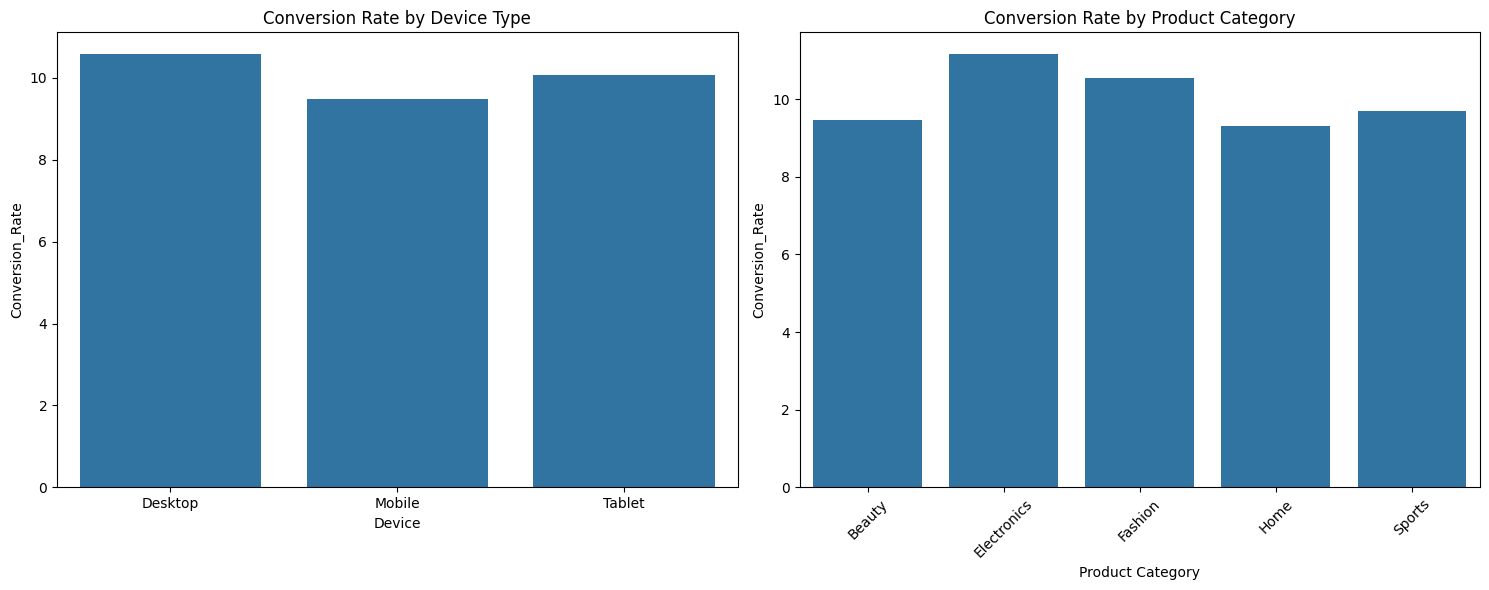

In [17]:
# Device performance
device_analysis = session_summary.groupby("Device").agg({
    'Session ID': 'count',
    'Revenue': 'sum',
    'Session_Duration_Min': 'mean',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns= {'Session ID':"Total_Sessions",'Max_Funnel_Stage':"Purchase"})

device_analysis['Conversion_Rate'] = (device_analysis["Purchase"] / device_analysis['Total_Sessions'] * 100).round(2)
device_analysis['AOV'] = (device_analysis["Revenue"] / device_analysis['Purchase']).round(2)

print("Device Performance:")
display(device_analysis)

# Product category analysis
product_analysis = session_summary.groupby("Product Category").agg({
    'Session ID': 'count',
    'Revenue': 'sum',
    'Max_Funnel_Stage': lambda x: (x == 'Purchase').sum()
}).rename(columns = {"Session ID":"Total_Sessions",'Max_Funnel_Stage':"Purchase"})

product_analysis['Conversion_Rate'] = (product_analysis["Purchase"] / product_analysis["Total_Sessions"] * 100).round(2)
product_analysis['AOV'] = (product_analysis["Revenue"] / product_analysis['Purchase']).round(2)
product_analysis['Revenue_Per_Session'] = (product_analysis['Revenue'] / product_analysis["Total_Sessions"]).round(2)

print("Product Category Performance:")
display(product_analysis)

# Combined Visualization
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(15,6))

# Device Performance
sns.barplot(data=device_analysis.reset_index(), x= "Device", y = 'Conversion_Rate', ax =ax1)
ax1.set_title('Conversion Rate by Device Type')

# Product Category Performance
sns.barplot(data= product_analysis.reset_index(),x ="Product Category", y = "Conversion_Rate", ax = ax2)
ax2.set_title('Conversion Rate by Product Category')
ax2.tick_params(axis = 'x', rotation =45)

plt.tight_layout()
plt.show()



# Time-Based Analysis

 Daily Performance Trends:


,Daily_Sessions,Daily_Users,Revenue,Daily_Conversions,Daily_Conversion_Rate
Date,,,,,
2025-12-30,317,317,9673.30,32,10.09
2025-12-31,338,338,9115.30,34,10.06
2026-01-01,345,345,5634.03,27,7.83
2026-01-02,322,322,9875.70,34,10.56
2026-01-03,344,344,12434.29,42,12.21
2026-01-04,320,320,6887.50,27,8.44
2026-01-05,331,331,9225.22,32,9.67
2026-01-06,367,367,10998.27,39,10.63
2026-01-07,341,341,12464.35,44,12.90


/tmp/ipykernel_58/343161989.py:33: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



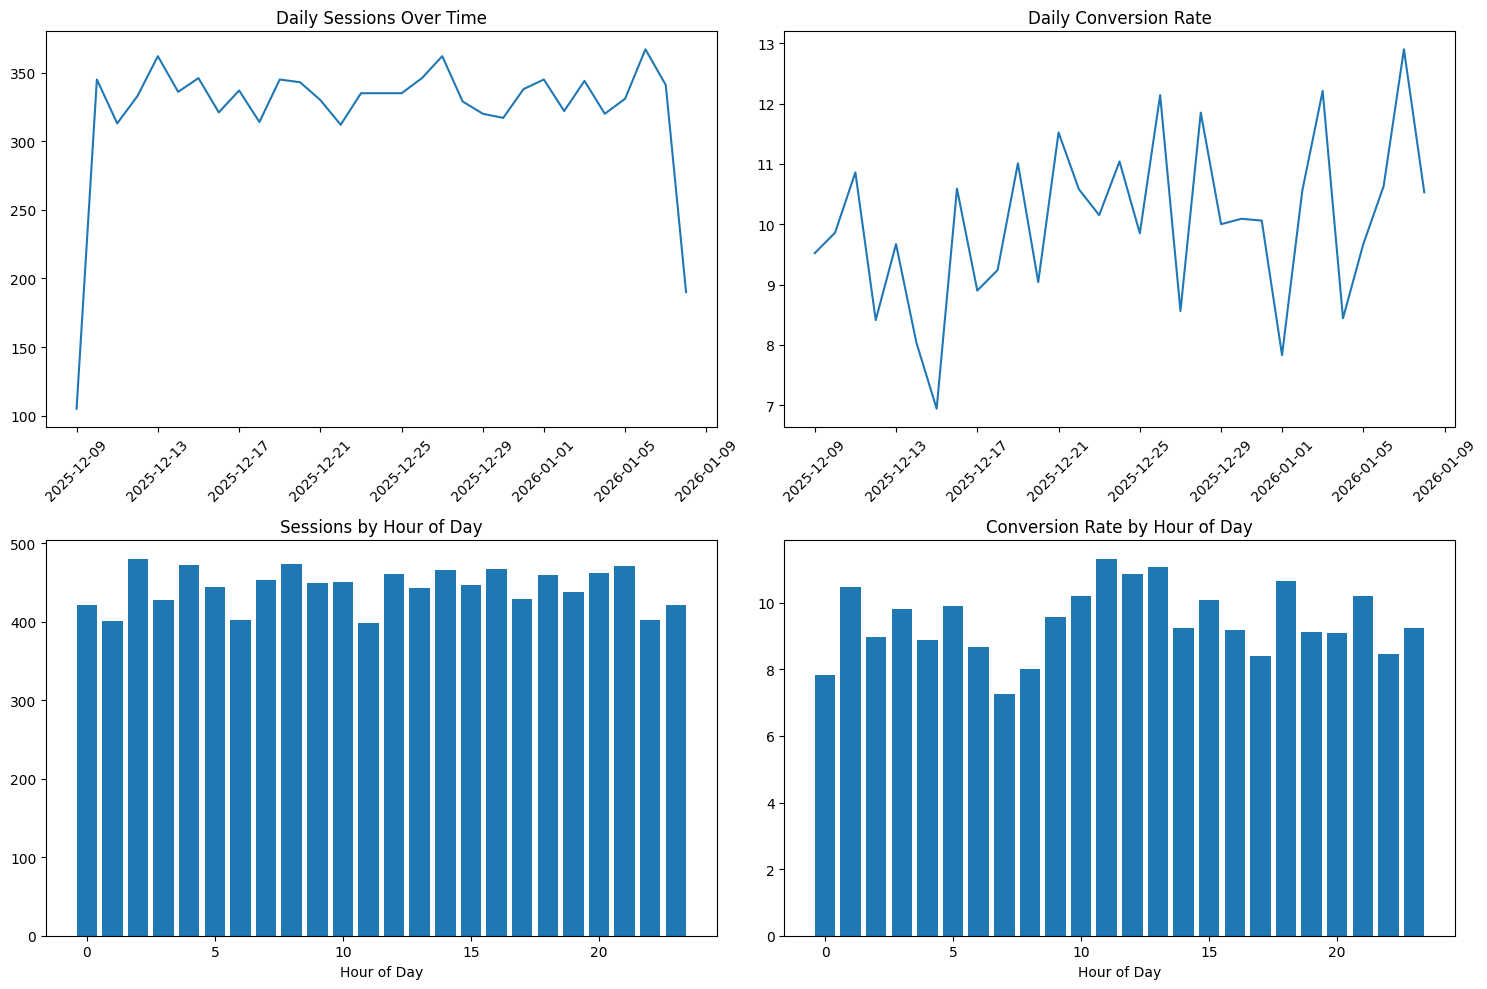

In [18]:
# Daily trends
daily_metrics = df.groupby('Date').agg({
    'Session ID': 'nunique',
    'User ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={
    'Session ID': 'Daily_Sessions',
    'User ID': 'Daily_Users'
})

# Add conversion rates daily
# Modify the problematic line to extract date from datetime
daily_conversions = session_summary[
    session_summary['Max_Funnel_Stage'] == 'Purchase'].groupby(
    session_summary['Session_Start'].dt.date
).size()

daily_metrics['Daily_Conversions'] = daily_conversions

daily_metrics['Daily_Conversion_Rate'] = (daily_metrics['Daily_Conversions'] / daily_metrics['Daily_Sessions'] * 100).round(2)

print(" Daily Performance Trends:")
display(daily_metrics.tail(10))


# Hourly patterns
hourly_sessions = df.groupby('Hour').agg({
    'Session ID': 'nunique',
    'Revenue': 'sum'
}).rename(columns={'Session ID': 'Hourly_Sessions'})

hourly_conversions = session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase']
hourly_conversions['Hour'] = hourly_conversions['Session_Start'].dt.hour
hourly_conversion_counts = hourly_conversions.groupby('Hour').size()
hourly_sessions['Hourly_Conversions'] = hourly_conversion_counts

hourly_sessions['Hourly_Conversion_Rate'] = ( hourly_sessions['Hourly_Conversions'] / hourly_sessions['Hourly_Sessions'] * 100).round(2)


# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

# Daily sessions
ax1.plot(daily_metrics.index,daily_metrics['Daily_Sessions'])
ax1.set_title('Daily Sessions Over Time')
ax1.tick_params(axis='x', rotation=45)

# Daily conversion rate
ax2.plot(daily_metrics.index,daily_metrics['Daily_Conversion_Rate'])
ax2.set_title('Daily Conversion Rate')
ax2.tick_params(axis='x', rotation=45)

# Hourly session pattern
ax3.bar(hourly_sessions.index,hourly_sessions['Hourly_Sessions'])
ax3.set_title('Sessions by Hour of Day')
ax3.set_xlabel('Hour of Day')

# Hourly conversion rate
ax4.bar(hourly_sessions.index,hourly_sessions['Hourly_Conversion_Rate'])
ax4.set_title('Conversion Rate by Hour of Day')
ax4.set_xlabel('Hour of Day')

plt.tight_layout()
plt.show()

# Advanced Funnel Metrics and KPIs 

In [19]:
# Calculate advanced metrics
print(" KEY PERFORMANCE INDICATORS (KPIs)")
print("="*50)

# Overall KPIs
total_sessions = len(session_summary)
total_revenue = session_summary['Revenue'].sum()
total_orders = len(session_summary[session_summary['Max_Funnel_Stage'] == 'Purchase'])
overall_conversion_rate = (total_orders / total_sessions * 100)

print(f" Overall Conversion Rate: {overall_conversion_rate:.2f}%")
print(f" Total Revenue: ${total_revenue:,.2f}")
print(f" Average Order Value: ${(total_revenue/total_orders):.2f}")
print(f" Total Sessions: {total_sessions:,}")
print(f" Total Orders: {total_orders:,}")

# Funnel efficiency metrics
browse_to_cart = (funnel_df.iloc[1]['Sessions'] / funnel_df.iloc[0]['Sessions'] * 100)
cart_to_checkout = (funnel_df.iloc[2]['Sessions'] / funnel_df.iloc[1]['Sessions'] * 100)
checkout_to_purchase = (funnel_df.iloc[3]['Sessions'] / funnel_df.iloc[2]['Sessions'] * 100)

print(f"\n Stage-to-Stage Conversion Rates:")
print(f"   Browse -> Add to Cart: {browse_to_cart:.2f}%")
print(f"   Add to Cart -> Checkout: {cart_to_checkout:.2f}%")
print(f"   Checkout -> Purchase: {checkout_to_purchase:.2f}%")

# Revenue per session at each stage
revenue_per_browse = total_revenue / funnel_df.iloc[0]['Sessions']
revenue_per_cart = total_revenue / funnel_df.iloc[1]['Sessions']
revenue_per_checkout = total_revenue / funnel_df.iloc[2]['Sessions']

# Bounce rate analysis
bounce_sessions = session_summary[session_summary['Bonus Flag'] == 'Yes']
bounce_rate = (len(bounce_sessions) / total_sessions * 100)
print(f"\n Bounce Rate: {bounce_rate:.2f}%")

# Session duration analysis
avg_session_duration = session_summary['Session_Duration_Min'].mean()
print(f" Average Session Duration: {avg_session_duration:.2f} minutes")



 KEY PERFORMANCE INDICATORS (KPIs)
 Overall Conversion Rate: 10.04%
 Total Revenue: $277,323.06
 Average Order Value: $276.22
 Total Sessions: 10,000
 Total Orders: 1,004

 Stage-to-Stage Conversion Rates:
   Browse -> Add to Cart: 69.49%
   Add to Cart -> Checkout: 49.73%
   Checkout -> Purchase: 29.05%

 Bounce Rate: 100.00%
 Average Session Duration: 3.99 minutes


# Strategic Recommendations

In [20]:
# Generate actionable insights
print(" STRATEGIC RECOMMENDATIONS")
print("="*50)

# Identify biggest drop-off points
max_dropoff_stage = funnel_df.loc[funnel_df['Drop_off_rate'].idxmax()]
print(f" BIGGEST DROP-OFF: {max_dropoff_stage['Stage']} stage with {max_dropoff_stage['Drop_off_rate']}% drop-off")

# Best performing channel
best_channel = channel_df.loc[channel_df['Conversion_Rate'].idxmax()]
print(f" BEST PERFORMING CHANNEL: {best_channel['Channel']} with {best_channel['Conversion_Rate']}% conversion")

# Best performing region
best_region = regional_analysis.loc[regional_analysis['Conversion_Rate'].idxmax()]
print(f" BEST PERFORMING REGION: {best_region.name} with {best_region['Conversion_Rate']}% conversion")

# Best performing product category
best_category = product_analysis.loc[product_analysis['Conversion_Rate'].idxmax()]
print(f" BEST PERFORMING CATEGORY: {best_category.name} with {best_category['Conversion_Rate']}% conversion")

print(f"\n RECOMMENDED ACTIONS:")
print(f"1. Address {max_dropoff_stage['Stage']} stage drop-off through UX improvements")
print(f"2. Allocate more budget to {best_channel['Channel']} channel")
print(f"3. Replicate {best_region.name} region strategies in underperforming regions")
print(f"4. Promote {best_category.name} category to improve overall conversion")
print(f"5. Focus on cart abandonment recovery for {funnel_df.iloc[2]['Drop_off_rate']}% of users")

# Calculate potential revenue opportunities
cart_abandonment_opportunity = funnel_df.iloc[2]['Sessions'] * product_analysis['AOV'].mean()
print(f"\n REVENUE OPPORTUNITY:")
print(f"   Cart abandonment recovery: ${cart_abandonment_opportunity:,.2f} potential revenue")



 STRATEGIC RECOMMENDATIONS
 BIGGEST DROP-OFF: Purchase stage with 70.95% drop-off
 BEST PERFORMING CHANNEL: Google Ads with 10.634920634920634% conversion
 BEST PERFORMING REGION: South with 10.54% conversion
 BEST PERFORMING CATEGORY: Electronics with 11.16% conversion

 RECOMMENDED ACTIONS:
1. Address Purchase stage drop-off through UX improvements
2. Allocate more budget to Google Ads channel
3. Replicate South region strategies in underperforming regions
4. Promote Electronics category to improve overall conversion
5. Focus on cart abandonment recovery for 50.27% of users

 REVENUE OPPORTUNITY:
   Cart abandonment recovery: $954,906.62 potential revenue


# Export Results

In [21]:
# # Create comprehensive report
# report_data = {
#     'Overall_Funnel': funnel_df,
#     'Channel_Performance': channel_df,
#     'Regional_Analysis': regional_analysis,
#     'Device_Performance': device_analysis,
#     'Product_Performance': product_analysis,
#     'Daily_Trends': daily_metrics,
#     'Hourly_Patterns': hourly_sessions
# }

# # Export to Excel for corporate reporting
# with pd.ExcelWriter('funnel_analysis_report.xlsx') as writer:
#     for sheet_name, data in report_data.items():
#         data.to_excel(writer, sheet_name=sheet_name, index=False)

# print(" Analysis complete! Report exported to 'funnel_analysis_report.xlsx'")

# # Save key visualizations
# plt.figure(figsize=(10, 6))
# sns.barplot(data=funnel_df, x='Stage', y='Conversion_Rate')
# plt.title('Overall Funnel Conversion Rates')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.savefig('funnel_conversion_rates.png', dpi=300, bbox_inches='tight')

# print("Key visualizations saved!")